<a href="https://colab.research.google.com/github/Manikanta898/AirBnb_Booking_Analysis/blob/main/AirBnb_Bookings_Analysis_EDA_Submission.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name**    



##### **Project Type**    - Exploratory Data Analysis
##### **Contribution**    - Individual


# **Project Summary**

Airbnb has changed the way we travel since 2008, offering unique experiences worldwide. With millions of listings, Airbnb collects a lot of data, around 49,000 observations in this dataset alone, with 16 columns mixing different types of information. This data is essential for many things, like making the platform safer, deciding on business strategies, understanding how users and hosts behave, evaluating performance, targeting ads better, and coming up with new services. Exploring this dataset helps Airbnb learn from its users and improve its services for everyone.

# **GitHub Link**

https://github.com/mani-github2021/AirBnb_Booking_Analysis

# **Problem Statement**


Analyze the Airbnb NYC 2019 dataset to understand various aspects of Airbnb listings in New York City, such as distribution, pricing, and relationships between different variables, and to provide insights that can help improve business strategies for hosts and Airbnb as a platform.
The analysis involves importing and examining the dataset, understanding the variables, performing data wrangling, and visualizing relationships between variables. Insights gained from the analysis will help Airbnb hosts and the platform optimize their offerings.

#### **Define Your Business Objective?**

To gain insights from the Airbnb NYC 2019 dataset that can help improve host performance, optimize pricing strategies, and enhance guest satisfaction. This includes understanding data distribution, identifying key factors affecting prices, and finding patterns that can be leveraged for better decision-making.

# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [ ]:
# Import Libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

### Dataset Loading

In [ ]:
# Load Dataset
path='/content/Airbnb NYC 2019.csv'
df = pd.read_csv(path)

### Dataset First View

In [ ]:
# Dataset First Look
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


### Dataset Rows & Columns count

In [ ]:
# Dataset Rows & Columns count
df.shape

(48895, 16)

### Dataset Information

In [ ]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

#### Duplicate Values

In [ ]:
# Dataset Duplicate Value Count
df.duplicated().sum()

0

#### Missing Values/Null Values

In [ ]:
# Missing Values/Null Values Count
df.isnull().sum()

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

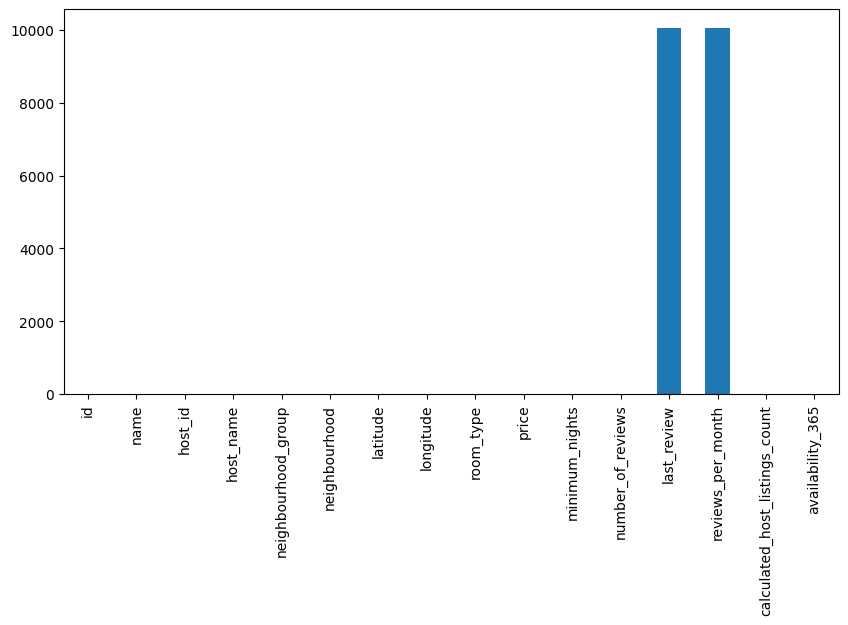

In [ ]:
# Visualizing the missing values
plt.rcParams['figure.figsize'] = (10,5)
df.isna().sum().plot.bar()
plt.show()

### What did you know about your dataset?

The dataset has 48895 rows and 16 columns with missing values in name,  host name, last_review, reviews per month

## ***2. Understanding Your Variables***

In [ ]:
# Dataset Columns
list(df.columns)

['id',
 'name',
 'host_id',
 'host_name',
 'neighbourhood_group',
 'neighbourhood',
 'latitude',
 'longitude',
 'room_type',
 'price',
 'minimum_nights',
 'number_of_reviews',
 'last_review',
 'reviews_per_month',
 'calculated_host_listings_count',
 'availability_365']

In [ ]:
# Dataset Describe
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


### Variables Description

*These are the variables in the dataset*

id: Unique identifier

name: Listing title

host_id: Host identifier

host_name: Host name

neighbourhood_group: Grouped neighbourhood

neighbourhood: Specific neighbourhood

latitude: Geographic latitude

longitude: Geographic longitude

room_type: Type of room

price: Listing price

minimum_nights: Minimum stay

number_of_reviews: Total reviews

last_review: Date of last review

reviews_per_month: Avg. reviews/month

calculated_host_listings_count: Host listings count

availability_365: Availability (days)

### Check Unique Values for each variable.

In [ ]:
# Check Unique Values for each variable.
for col in df.columns:
    print(f"Number of unique value for {col} is : {len(df[col].unique())}")

Number of unique value for id is : 48895
Number of unique value for name is : 47906
Number of unique value for host_id is : 37457
Number of unique value for host_name is : 11453
Number of unique value for neighbourhood_group is : 5
Number of unique value for neighbourhood is : 221
Number of unique value for latitude is : 19048
Number of unique value for longitude is : 14718
Number of unique value for room_type is : 3
Number of unique value for price is : 674
Number of unique value for minimum_nights is : 109
Number of unique value for number_of_reviews is : 394
Number of unique value for last_review is : 1765
Number of unique value for reviews_per_month is : 938
Number of unique value for calculated_host_listings_count is : 47
Number of unique value for availability_365 is : 366


## 3. ***Data Wrangling***

### Data Wrangling Code

In [ ]:
# Remove duplicates
df = df.drop_duplicates()

# Handle missing values (filling or dropping)
df = df.dropna(subset=['name', 'host_name'])  # Dropping rows where 'name' or 'host_name' is missing
df['reviews_per_month'].fillna(0, inplace=True)  # Filling missing reviews per month with 0


In [ ]:
#Assigning data without and with certain conditions
# Data without reviews
df_no_reviews = df[df['reviews_per_month'] == 0]

# Data with reviews
df_with_reviews = df[df['reviews_per_month'] > 0]

In [ ]:
#Number of listings for each neighborhood group
df['neighbourhood_group'].value_counts().reset_index(name='listings')

,neighbourhood_group,listings
0,Manhattan,21643
1,Brooklyn,20089
2,Queens,5664
3,Bronx,1089
4,Staten Island,373


In [ ]:
#Number of listings for each neighborhood
df['neighbourhood'].value_counts().reset_index(name='listings')

,neighbourhood,listings
0,Williamsburg,3917
1,Bedford-Stuyvesant,3713
2,Harlem,2655
3,Bushwick,2462
4,Upper West Side,1969
...,...,...
216,Fort Wadsworth,1
217,Richmondtown,1
218,New Dorp,1
219,Rossville,1


In [ ]:
#Number of listings by room type without reviews
df_no_reviews['room_type'].value_counts().reset_index(name='listings')

,room_type,listings
0,Entire home/apt,5072
1,Private room,4652
2,Shared room,313


In [ ]:
#Number of listings by room type with reviews
df_with_reviews['room_type'].value_counts().reset_index(name='listings')

,room_type,listings
0,Entire home/apt,20321
1,Private room,17654
2,Shared room,846


In [ ]:
#Calculating the percentage of hosts with reviews
total_hosts = df['host_id'].nunique()
hosts_with_reviews = df_with_reviews['host_id'].nunique()
percentage_hosts_with_reviews = (hosts_with_reviews / total_hosts) * 100
print(f"Percentage of hosts with reviews: {percentage_hosts_with_reviews:.2f}%")

Percentage of hosts with reviews: 80.78%


### What all manipulations have you done and insights you found?

Removed duplicate entries to ensure data integrity.

Dropped rows with missing 'name' or 'host_name' to maintain essential information.

Filled missing 'reviews_per_month' with 0 to handle null values effectively.

Grouped data by neighborhood and room type to understand distribution and concentration.
- Manhattan has the Maximum Number of listings with 21643 among neighborhood groups
- Staten island has the Minimum Number of listings with 373 among neighborhood groups

Separated data based on the presence of reviews to analyze differences in listing characteristics.
- Entire home/apt has maximum Number of listings with 5072 by room type without reviews
- Shared room has minimum Number of listings with 313 by room type without reviews

Counted listings per neighborhood group and room type to identify popular areas and types.
- Entire home/apt is identified as popular with maximum Number of listings with 20321

Calculated the percentage of hosts with reviews to gauge engagement.
- Percentage of hosts with reviews: 80.78%

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

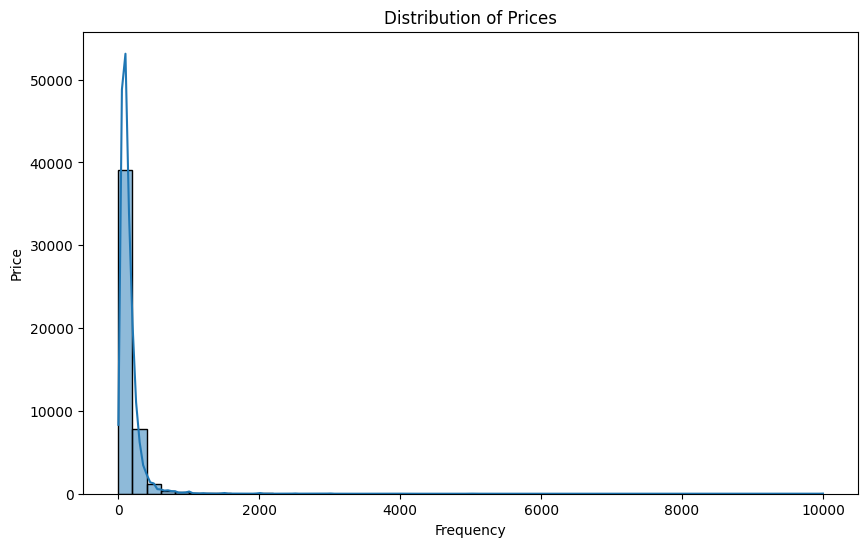

In [ ]:
#Distribution of Prices
plt.figure(figsize=(10, 6))
sns.histplot(df['price'], bins=50, kde=True)
plt.title('Distribution of Prices')
plt.xlabel('Frequency')
plt.ylabel('Price')
plt.show()

##### 1. Why did you pick the specific chart?

Histplot can be utilized to visualize the distribution of a dataset, showing the frequency of values within specified bins. I used this chart to understand the price distribution of Airbnb listings.

##### 2. What is/are the insight(s) found from the chart?

Most listings are priced below $500. There are a few listings with extremely high prices.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Helps the hosts understand the competitive pricing.

#### Chart - 2

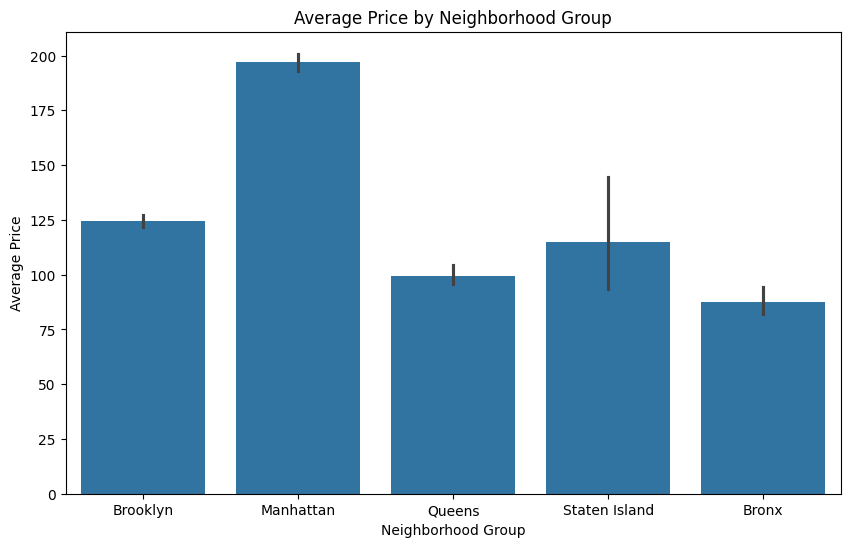

In [ ]:
#Average Price by Neighborhood Group
plt.figure(figsize=(10, 6))
sns.barplot(x='neighbourhood_group', y='price', data=df)
plt.title('Average Price by Neighborhood Group')
plt.xlabel('Neighborhood Group')
plt.ylabel('Average Price')
plt.show()

##### 1. Why did you pick the specific chart?

Bar charts show the frequency counts of values for the different labels of a categorical or nominal variable.I used this to compare average prices across different neighborhoods.

##### 2. What is/are the insight(s) found from the chart?

*   We see the average price is high in Manhattan among them.
*   And Bronx has lowest average price



##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Helps hosts in setting appropriate prices based on location.

#### Chart - 3

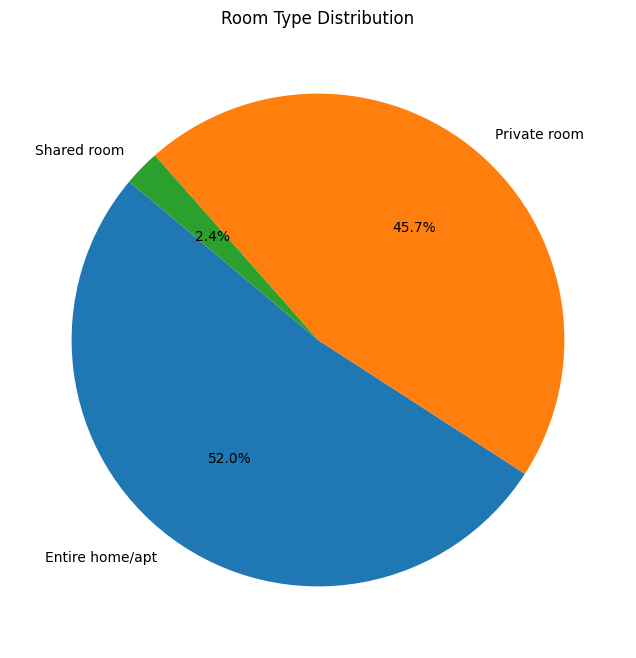

In [ ]:
# Room Type Distribution
plt.figure(figsize=(8, 8))
room_counts = df['room_type'].value_counts()
plt.pie(room_counts, labels=room_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Room Type Distribution')
plt.show()

##### 1. Why did you pick the specific chart?

A pie chart is a circular statistical graphic divided into slices to illustrate numerical proportions. I picked this chart to understand the popularity of each type of room.

##### 2. What is/are the insight(s) found from the chart?

*   Entire home/apt is in high demand and shared rooms are in less demand



##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Helps hosts on the most in-demand room types.

#### Chart - 4

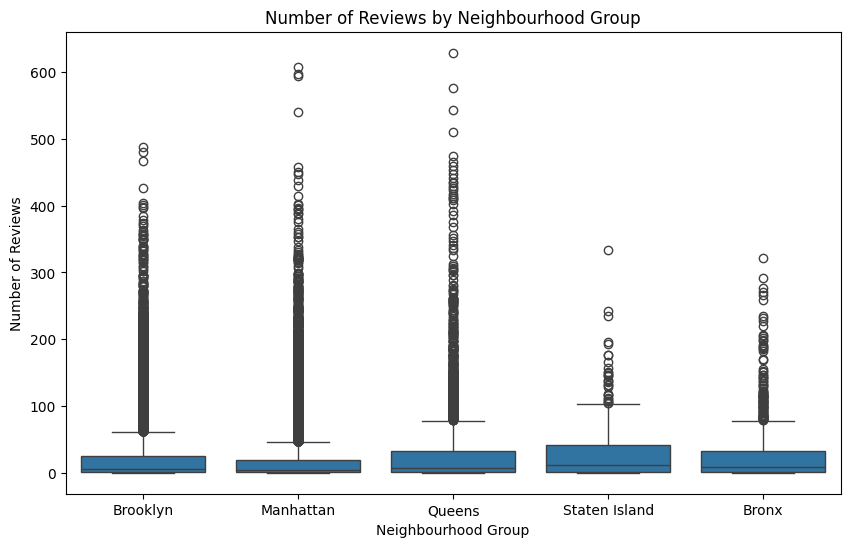

In [ ]:
#Number of Reviews by Neighbourhood Group
plt.figure(figsize=(10, 6))
sns.boxplot(x='neighbourhood_group', y='number_of_reviews', data=df)
plt.title('Number of Reviews by Neighbourhood Group')
plt.xlabel('Neighbourhood Group')
plt.ylabel('Number of Reviews')
plt.show()

##### 1. Why did you pick the specific chart?

A boxplot visually represents the distribution of a dataset by displaying its summary statistics in a concise manner. I picked this chart to see how availability varies across neighborhoods.

##### 2. What is/are the insight(s) found from the chart?

* Manhattan: Listings tend to be available fewer days, suggesting they are booked more often, indicating a high-demand area.
* Queens, Staten Island, and Bronx: Listings show higher availability, which might indicate less demand in these neighborhoods.
* Brooklyn: Shows moderate availability, indicating a balanced demand where listings are neither excessively booked nor overly available.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Helps hosts manage expectations and strategies based on availability trends.

#### Chart - 5

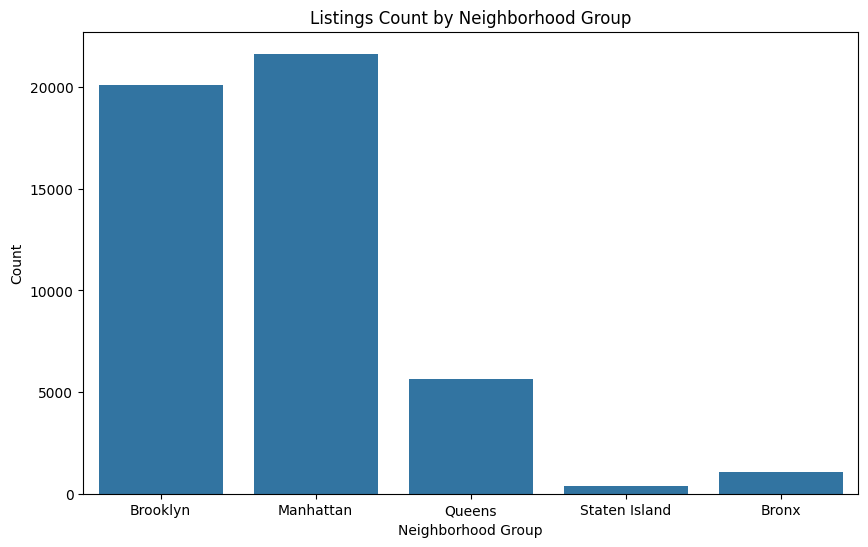

In [ ]:
#Listings Count by Neighborhood Group
plt.figure(figsize=(10, 6))
sns.countplot(x='neighbourhood_group', data=df)
plt.title('Listings Count by Neighborhood Group')
plt.xlabel('Neighborhood Group')
plt.ylabel('Count')
plt.show()

##### 1. Why did you pick the specific chart?

A countplot is used to show the frequency of categorical data using bars.I used this to see the distribution of listings across different neighborhoods.

##### 2. What is/are the insight(s) found from the chart?

*   Manhattan has the maximum counts
*   Staten island has the minimum counts among the neighborhood groups.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Helps in understanding market saturation and potential opportunities.

#### Chart - 6

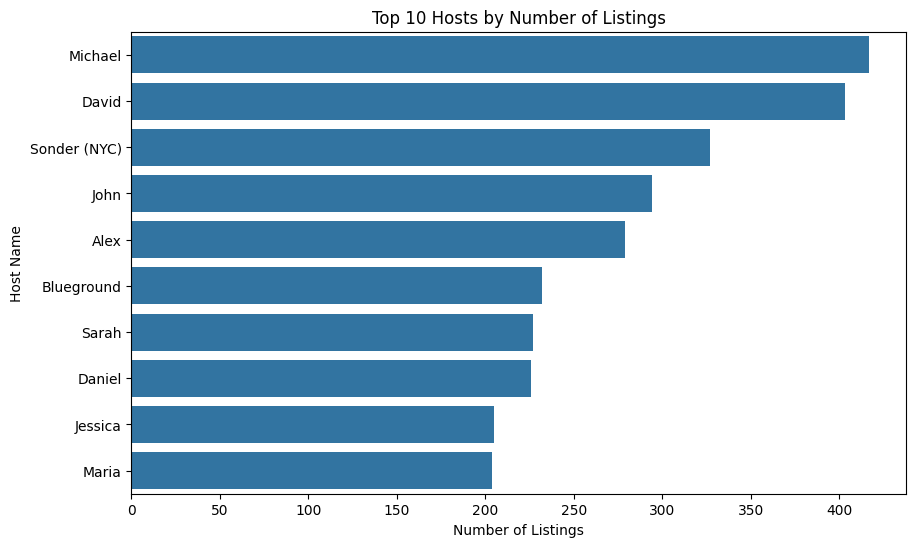

In [ ]:
#Top 10 Hosts by Number of Listings
top_hosts = df['host_name'].value_counts().head(10)
plt.figure(figsize=(10, 6))
sns.barplot(x=top_hosts.values, y=top_hosts.index)
plt.title('Top 10 Hosts by Number of Listings')
plt.xlabel('Number of Listings')
plt.ylabel('Host Name')
plt.show()

##### 1. Why did you pick the specific chart?

A horizontal bar plot is useful for visualizing categorical data where the length of each bar corresponds to the frequency or proportion of each category. It is chosen o identify the most active hosts in the NYC Airbnb market.

##### 2. What is/are the insight(s) found from the chart?

* The Host - Michael is recognized as the person with most number of listings above 400

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

It helps in understanding competition and potential partnership opportunities.

#### Chart - 7

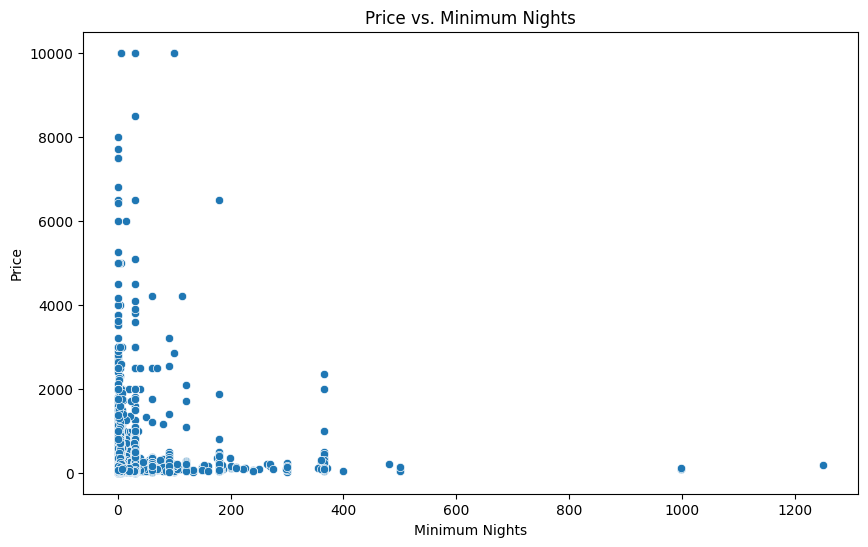

In [ ]:
# Relation between Price and Minimum nights
plt.figure(figsize=(10, 6))
sns.scatterplot(x='minimum_nights', y='price', data=df)
plt.title('Price vs. Minimum Nights')
plt.xlabel('Minimum Nights')
plt.ylabel('Price')
plt.show()

##### 1. Why did you pick the specific chart?

A scatter plot is used to visualize the relationship between two continuous variables, showing how one variable changes in relation to another I used this to visualize the pairwise relationships between multiple variables.

##### 2. What is/are the insight(s) found from the chart?

* There are several outliers with prices above 2000, and some even reach up to 10,000.
* These high-priced listings tend to have low minimum night requirements, typically below 100 nights.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Assists hosts in setting minimum stay requirements based on pricing strategies.

#### Chart - 8

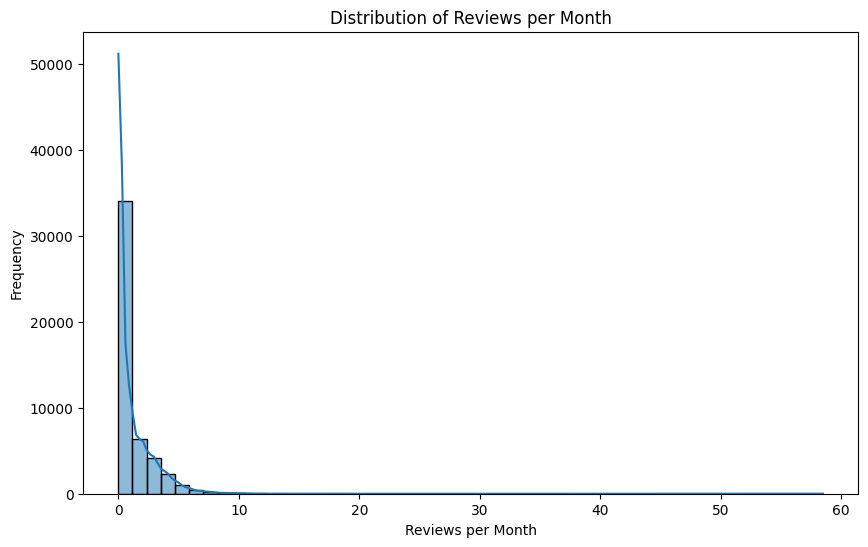

In [ ]:
# Distribution of Reviews per Month
plt.figure(figsize=(10, 6))
sns.histplot(df['reviews_per_month'], bins=50, kde=True)
plt.title('Distribution of Reviews per Month')
plt.xlabel('Reviews per Month')
plt.ylabel('Frequency')
plt.show()

##### 1. Why did you pick the specific chart?

Histplot can be utilized to visualize the distribution of a dataset, showing the frequency of values within specified bins. I used this chart to understand the Distribution of Reviews per Month.

##### 2. What is/are the insight(s) found from the chart?

* The histogram shows a right-skewed distribution, indicating that the majority of listings receive few reviews per month.
* Most listings get between 0 to 5 reviews per month.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Highlights the popularity and guest engagement of listings.

#### Chart - 9

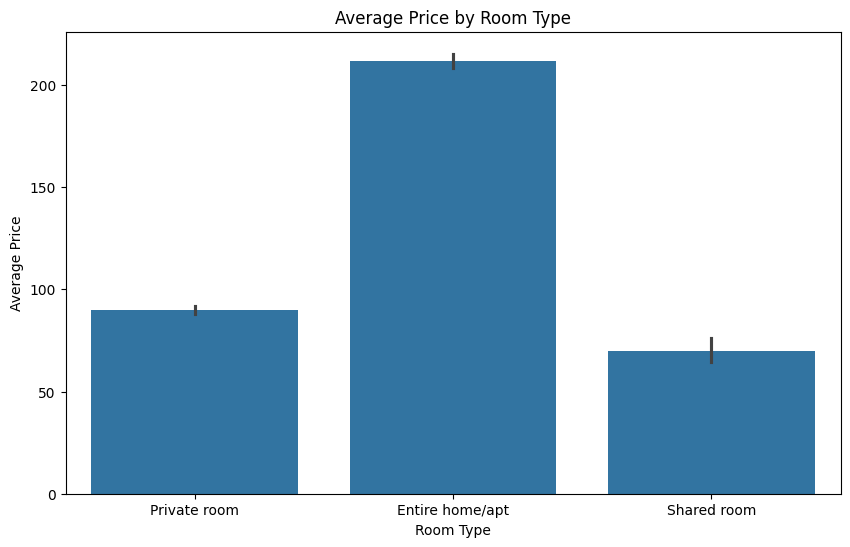

In [ ]:
# Average Price by Room Type
plt.figure(figsize=(10, 6))
sns.barplot(x='room_type', y='price', data=df)
plt.title('Average Price by Room Type')
plt.xlabel('Room Type')
plt.ylabel('Average Price')
plt.show()

##### 1. Why did you pick the specific chart?

Bar charts show the frequency counts of values for the different labels of a categorical or nominal variable.I used this to compare average prices across different room types.

##### 2. What is/are the insight(s) found from the chart?

* Entire home/apt room type has a maximum average price.
* Shared room type has a minimum average price.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Guides hosts on pricing strategies based on room type.

#### Chart - 10

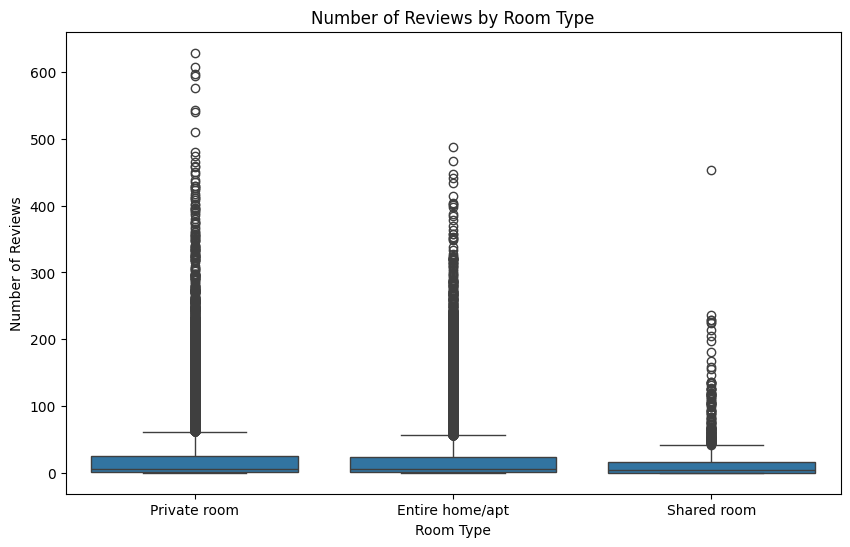

In [ ]:
# Number of Reviews by Room Type
plt.figure(figsize=(10, 6))
sns.boxplot(x='room_type', y='number_of_reviews', data=df)
plt.title('Number of Reviews by Room Type')
plt.xlabel('Room Type')
plt.ylabel('Number of Reviews')
plt.show()

##### 1. Why did you pick the specific chart?

A boxplot visually represents the distribution of a dataset by displaying its summary statistics in a concise manner. I picked this chart to see how the number of reviews varies by room type.

##### 2. What is/are the insight(s) found from the chart?

* Private room and Entire home/apt have more outliers compared to Shared room, these two types are more frequently booked and reviewed.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Helps understand guest preferences and engagement.

#### Chart - 11

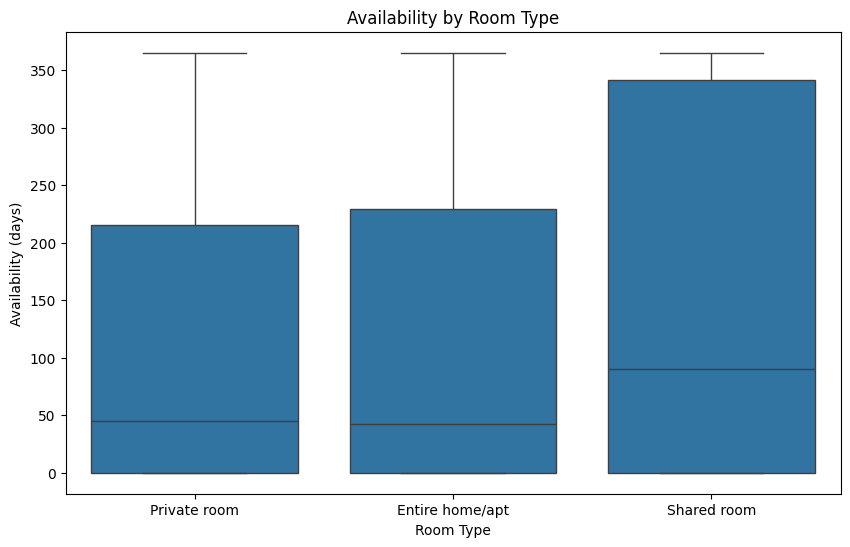

In [ ]:
# Availability by Room Type
plt.figure(figsize=(10, 6))
sns.boxplot(x='room_type', y='availability_365', data=df)
plt.title('Availability by Room Type')
plt.xlabel('Room Type')
plt.ylabel('Availability (days)')
plt.show()

##### 1. Why did you pick the specific chart?

I used this chart to analyze the availability of listings based on room type.

##### 2. What is/are the insight(s) found from the chart?

* Shared room listings show a higher overall availability compared to Private room and Entire home/apt listings.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Assists in optimizing availability and pricing strategies.

#### Chart - 12

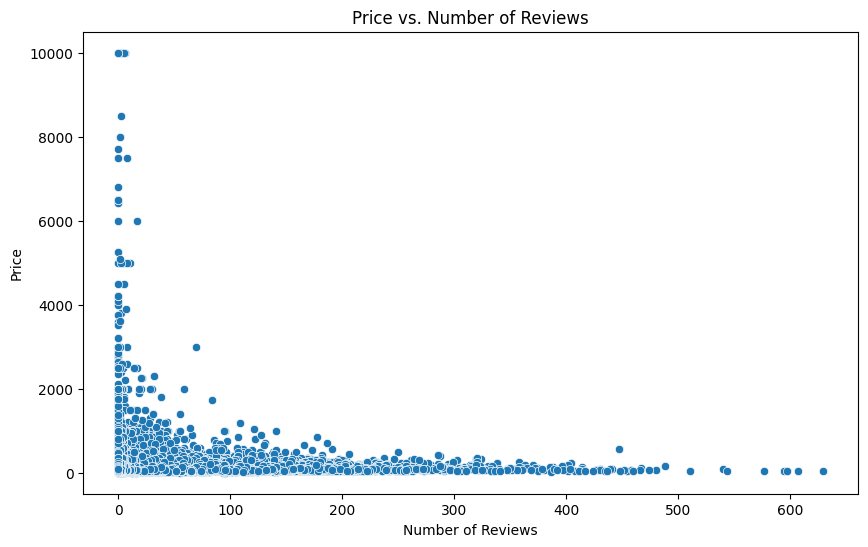

In [ ]:
# Price vs. Number of Reviews
plt.figure(figsize=(10, 6))
sns.scatterplot(x='number_of_reviews', y='price', data=df)
plt.title('Price vs. Number of Reviews')
plt.xlabel('Number of Reviews')
plt.ylabel('Price')
plt.show()

##### 1. Why did you pick the specific chart?

To explore the relationship between price and the number of reviews.

##### 2. What is/are the insight(s) found from the chart?

* As the number of reviews increases, the prices of products tend to be lower. Products with more than 100 reviews mostly have prices below 500.
* There are several products with very high prices, some reaching up to 10,000.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Helps understand the impact of reviews on pricing strategies.

#### Chart - 13

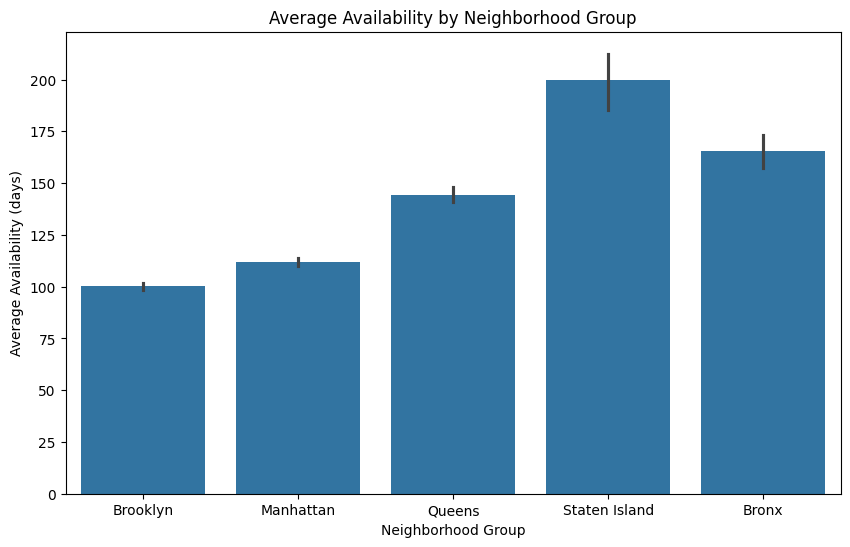

In [ ]:
# Average Availability by Neighborhood Group
plt.figure(figsize=(10, 6))
sns.barplot(x='neighbourhood_group', y='availability_365', data=df)
plt.title('Average Availability by Neighborhood Group')
plt.xlabel('Neighborhood Group')
plt.ylabel('Average Availability (days)')
plt.show()

##### 1. Why did you pick the specific chart?

To compare average availability across different neighborhoods.

##### 2. What is/are the insight(s) found from the chart?

Staten island is considered as highly available neighbourhood group whereas Brooklyn is less available.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Guides hosts on availability expectations based on location.

#### Chart - 14 - Correlation Heatmap

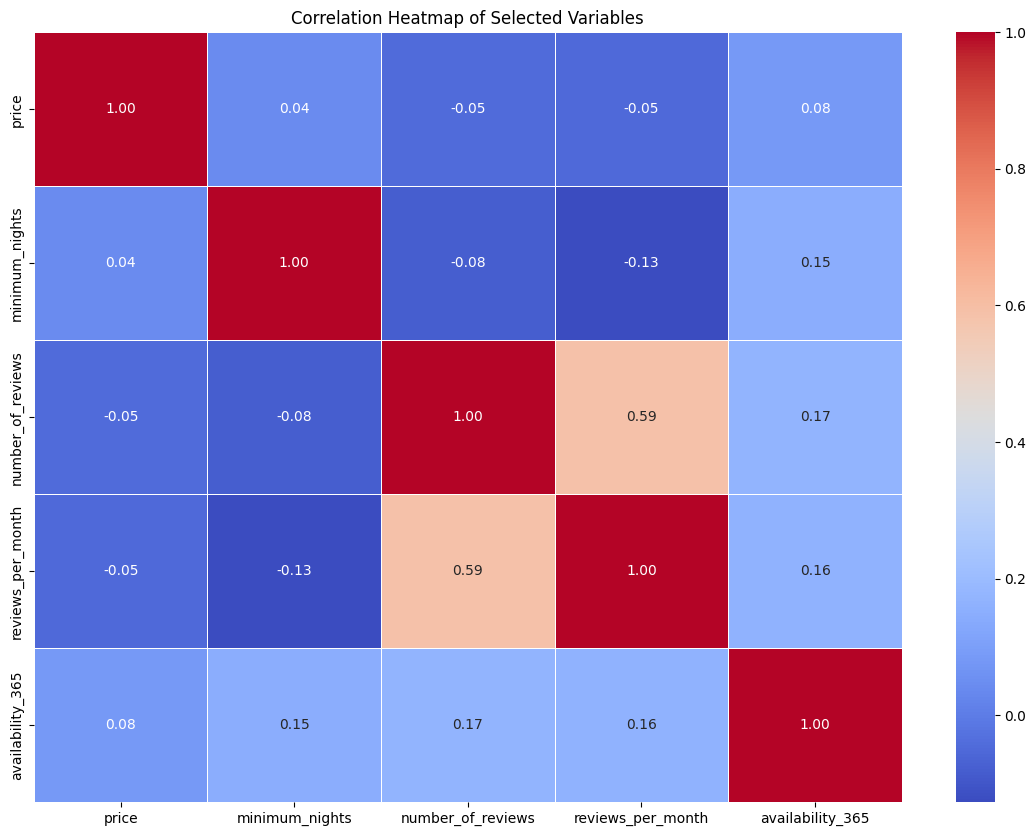

In [ ]:
# Correlation Heatmap visualization code
# Selecting relevant numerical variables for the heatmap
corr_variables = ['price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'availability_365']
# Calculating the correlation matrix
corr_matrix = df[corr_variables].corr()
# Plot the correlation heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Selected Variables')
plt.show()

##### 1. Why did you pick the specific chart?

A heatmap is a graphical representation of data where colors represent values, useful for visualizing correlations or distributions.I used this chart to examine the strength and direction of relationships between multiple numerical variables.

##### 2. What is/are the insight(s) found from the chart?

*   There is a weak negative correlation (-0.13), indicating that listings with longer minimum stays receive fewer reviews per month.
*   There is a moderate positive correlation (0.59), indicating that listings with a higher number of reviews tend to get more reviews per month.



##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Identifies key variables that influence important metrics like price and availability, helping to refine pricing strategies and improve listing performance.

#### Chart - 15 - Pair Plot

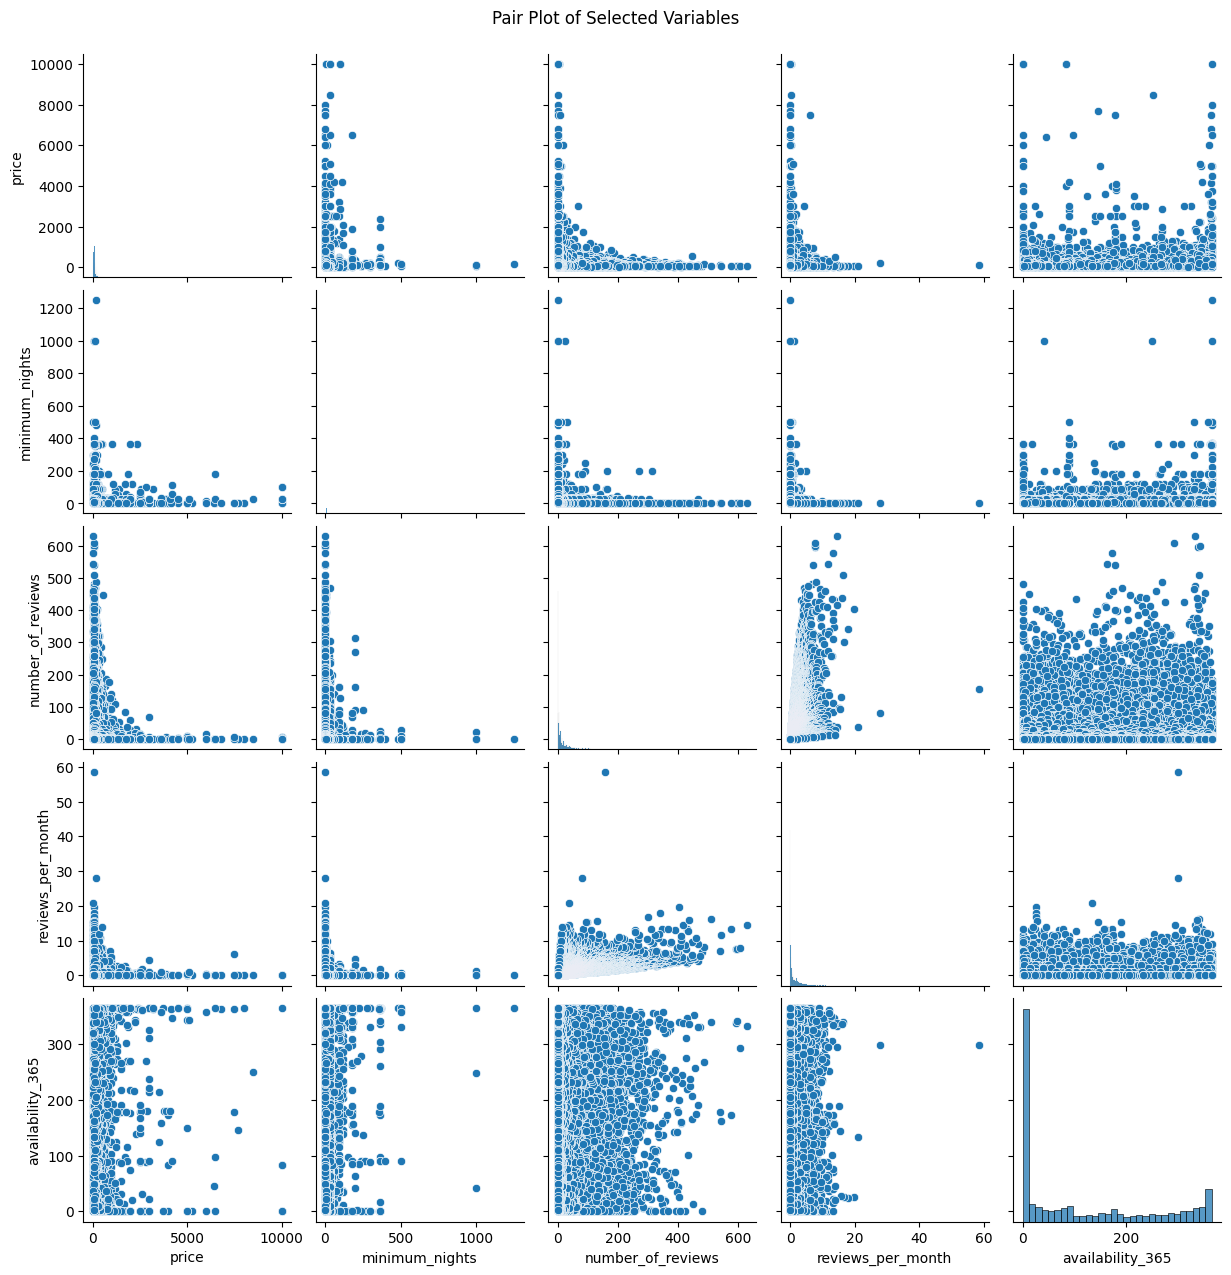

In [ ]:
# Pair Plot visualization code

# Selecting relevant numerical variables for the pair plot
pairplot_variables = ['price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'availability_365']

# Plot the pair plot
sns.pairplot(df[pairplot_variables])
plt.suptitle('Pair Plot of Selected Variables', y=1.02)  # Adjust the y-position of the title
plt.show()

##### 1. Why did you pick the specific chart?

A pair plot is used to visualize pairwise relationships between variables in a dataset and I used this to visualize the pairwise relationships between these variables - 'price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'availability_365'.

##### 2. What is/are the insight(s) found from the chart?

* Price vs. Number of Reviews: There is a clear negative correlation between price and the number of reviews. Lower-priced listings tend to receive more reviews.

* Price vs. Minimum Nights: Higher-priced listings often have a wider range of minimum night requirements, but most listings have lower minimum night stays.

* Price vs. Reviews per Month: Listings with higher prices generally receive fewer reviews per month, suggesting that more affordable listings are booked more frequently.

* Price vs. Availability: Listings with very high availability (close to 365 days) tend to have lower prices, indicating that more expensive listings might not be booked as often.

* Minimum Nights vs. Number of Reviews: Listings with lower minimum night requirements tend to have more reviews, suggesting that shorter stays are more popular among guests.

* Minimum Nights vs. Reviews per Month: Listings with lower minimum night requirements generally have higher reviews per month, further indicating the preference for short-term stays.

* Number of Reviews vs. Reviews per Month: Listings with more overall reviews also tend to have higher reviews per month, indicating consistent guest engagement over time.

* Number of Reviews vs. Availability: There is a wide distribution of availability for listings with a high number of reviews, but generally, those with fewer reviews have higher availability, suggesting they are less frequently booked.

* Reviews per Month vs. Availability: Listings with higher reviews per month tend to have lower availability, indicating higher occupancy rates.

* Overall Distribution:

* Most listings have prices concentrated at the lower end of the scale, with a few outliers.
* Minimum nights for most listings are on the lower side, with some listings having very high minimum night requirements.
* The majority of listings have a relatively low number of reviews and reviews per month.
* Availability is distributed with a significant number of listings available throughout the year.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Helps to identify patterns and potential outliers in the data, providing a comprehensive view of how different variables interact.

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?

* Set competitive prices based on neighbourhood and property type. For instance, listings in Manhattan can be priced higher due to higher demand
* Focus on improving listing reviews by enhancing guest experience and encouraging reviews. Listings with higher reviews tend to attract more bookings.
* Invest in neighborhoods like Williamsburg or Bedford-Stuyvesant to increase occupancy rates.
* Offer more entire home/apartment listings in high-demand areas, as they command higher prices and attract different guest segments.
* Adopt flexible or moderate cancellation policies, especially in Manhattan and Brooklyn, to attract more bookings.
* Adjust prices based on availability trends and seasonal demand to optimize occupancy and revenue throughout the year.

# **Conclusion**

By leveraging these insights and recommendations, Airbnb hosts and investors can make informed decisions to enhance their market presence, optimize occupancy rates, and maximize revenue in the dynamic NYC Airbnb market.

# ***Video Explanation Link***

https://drive.google.com/file/d/1hcodzdgiHUtghvL7Za3cpk5XIKGUGp12/view?usp=sharing